# The shape of a throw

Every model in this project so far has described a player by one number: an isotropic
$\sigma$, a round cloud of darts. Real throws are not round. A dart is released along an
arc, so timing errors move it up and down while aim errors move it side to side, and the
two are not the same size -- most players' groups are visibly taller than they are wide.

Notebook 11 listed anisotropy as the first thing to relax. This notebook does it, and asks
three questions in order:

1. **Does the shape change the board?** Does a tall thrower face a different game from a
   round one with the same overall spread?
2. **Can the shape be learned?** From match-play scores alone, can a posterior tell a tall
   thrower from a wide one?
3. **What does ignoring it cost?** If a genuinely anisotropic player is modelled as round,
   how many visits per leg does that throw away?

Question 1 has to come first, because if the answer is no, the other two do not matter.

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import DARTBOARD_CONSTANTS as C, generate_dartboard
from darts.throw_shape import (ShapeRecommender, ThrowPosterior,
                               isotropic_equivalent, play_leg, shape_prior,
                               sigma_matrices)
from darts.utils import aim_description, mm_per_pixel

PX = 512
STRIDE = 4
BOARD, CHECKOUTS = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2

# the player this notebook follows: a tall, narrow group
TALL = np.array([[12.0 ** 2, 0.0], [0.0, 20.0 ** 2]])
WIDE = np.array([[20.0 ** 2, 0.0], [0.0, 12.0 ** 2]])
ROUND = isotropic_equivalent(TALL) ** 2 * np.eye(2)
print(f'tall  sigma_x=12 sigma_y=20 -> isotropic equivalent '
      f'{isotropic_equivalent(TALL):.2f} mm')
print(f'round sigma   ={isotropic_equivalent(ROUND):.2f} mm (same overall spread)')

tall  sigma_x=12 sigma_y=20 -> isotropic equivalent 16.49 mm
round sigma   =16.49 mm (same overall spread)


## 1. Does the shape change the board?

Take the doubles. A double bed is a thin arc: 8 mm deep in the radial direction and about
52 mm long around the ring. Which of those two dimensions your error runs into depends
entirely on **where on the board the bed sits**.

At D20, at the top, a vertical miss moves you radially -- straight out of the 8 mm ring.
At D6, on the right-hand side, a vertical miss moves you *along* the ring, where you have
52 mm to play with, and it is the horizontal error that has to fit inside 8 mm.

So a thrower with a tall group should find the side doubles far easier than the top and
bottom ones, and a wide thrower the reverse. That is a prediction, and it is checkable.

In [2]:
coords = (np.arange(PX) - CENTRE) * MM
X, Y = np.meshgrid(coords, coords)

def p_hit_double(number, Sigma, radius=166.0):
    '''Probability of hitting a specific double, aiming at the middle of its bed.'''
    lo, hi = C['SEGMENTS'][number][0]
    theta = (lo + hi) / 2 * np.pi
    ax, ay = radius * np.cos(theta), radius * np.sin(theta)
    inv = np.linalg.inv(Sigma)
    dx, dy = X - ax, Y - ay
    q = inv[0, 0] * dx ** 2 + 2 * inv[0, 1] * dx * dy + inv[1, 1] * dy ** 2
    w = np.exp(-0.5 * q)
    w /= w.sum()
    return float(w[(BOARD == 2 * number) & CHECKOUTS].sum()), np.degrees(theta)

rows = []
for n in C['SEGMENTS']:
    p_tall, ang = p_hit_double(n, TALL)
    p_wide, _ = p_hit_double(n, WIDE)
    p_round, _ = p_hit_double(n, ROUND)
    rows.append({'double': f'D{n}', 'angle': ang % 360,
                 'tall (12x20)': p_tall, 'round (16.5)': p_round,
                 'wide (20x12)': p_wide})
doubles = pd.DataFrame(rows).sort_values('angle').reset_index(drop=True)
print('all three players have the same isotropic-equivalent spread')
doubles.round(4).head(20)

all three players have the same isotropic-equivalent spread


,double,angle,tall (12x20),round (16.5),wide (20x12)
0,D6,0.0,0.2090,0.1685,0.1529
1,D13,18.0,0.2034,0.1697,0.1577
2,D4,36.0,0.1853,0.1686,0.1685
3,D18,54.0,0.1690,0.1694,0.1860
4,D1,72.0,0.1577,0.1697,0.2034
5,D20,90.0,0.1529,0.1685,0.2090
6,D5,108.0,0.1577,0.1697,0.2034
7,D12,126.0,0.1685,0.1686,0.1853
8,D9,144.0,0.1860,0.1694,0.1690
9,D14,162.0,0.2034,0.1697,0.1577


tall thrower: best D6 at 0.2090, worst D3 at 0.1529 -- a factor of 1.37


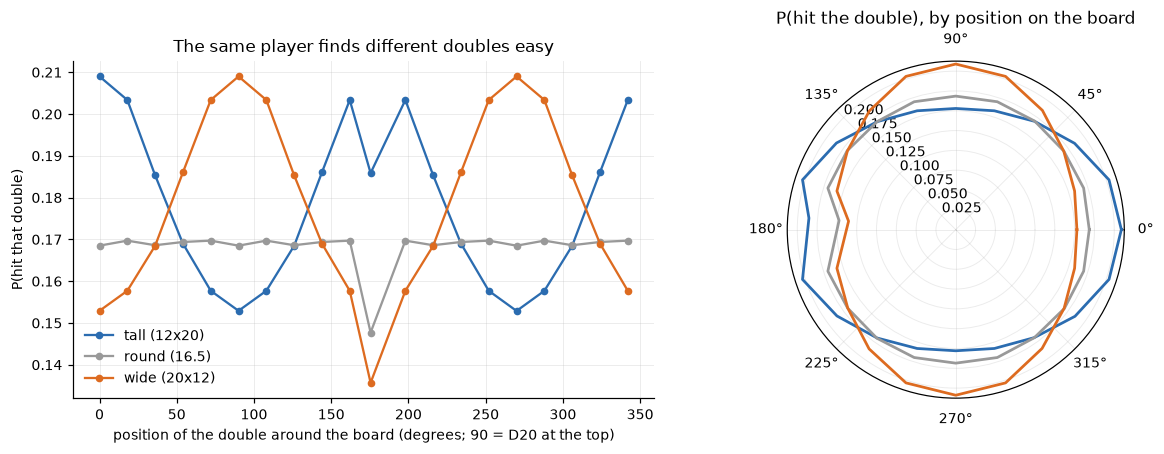

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ang = np.deg2rad(doubles.angle.values)
for col, colour in [('tall (12x20)', '#2b6cb0'), ('round (16.5)', '#999'),
                    ('wide (20x12)', '#dd6b20')]:
    axes[0].plot(doubles.angle, doubles[col], 'o-', ms=4, color=colour, label=col)
axes[0].set_xlabel('position of the double around the board (degrees; 90 = D20 at the top)')
axes[0].set_ylabel('P(hit that double)')
axes[0].set_title('The same player finds different doubles easy')
axes[0].legend()

ax = fig.add_subplot(1, 2, 2, projection='polar')
axes[1].remove()
order = np.argsort(ang)
for col, colour in [('tall (12x20)', '#2b6cb0'), ('round (16.5)', '#999'),
                    ('wide (20x12)', '#dd6b20')]:
    v = doubles[col].values[order]
    a = np.append(ang[order], ang[order][0])
    ax.plot(a, np.append(v, v[0]), color=colour, lw=1.8, label=col)
ax.set_title('P(hit the double), by position on the board')
ax.set_rlabel_position(135)
fig.tight_layout()

best_tall = doubles.loc[doubles['tall (12x20)'].idxmax()]
worst_tall = doubles.loc[doubles['tall (12x20)'].idxmin()]
print(f"tall thrower: best {best_tall.double} at {best_tall['tall (12x20)']:.4f}, "
      f"worst {worst_tall.double} at {worst_tall['tall (12x20)']:.4f} "
      f"-- a factor of {best_tall['tall (12x20)']/worst_tall['tall (12x20)']:.2f}")

The prediction holds exactly, and the size of it is the surprise. All three players have
the **same overall spread**, and the tall thrower's chance of hitting a double swings from
0.209 at D6, on the right-hand side, down to 0.153 at D20 and D3 at the top and bottom --
a factor of **1.37** between the best and worst double on the board, purely from where the
bed sits relative to the shape of their group.

Note where the best and worst fall: D6 sits at 0 degrees, D20 and D3 at 90 and 270. The
extremes land precisely on the axes the argument above picks out, with no fudging.

The wide thrower is the exact mirror image, best at D20 and D3 at the top and bottom. The
round thrower is nearly flat, as it must be: a round cloud has no preferred direction, and
the only variation left is the slight difference between the segments themselves.

So the shape of a throw does change the board, and by enough that a checkout chart built
for a round player is giving a tall player the wrong doubles.

## Solving the game for each shape

If the shape changes which shots are good, it changes the value function, and every
covariance needs its own solve. That is the expensive part of anisotropy and the reason it
could not simply be bolted onto the earlier model: a grid over $(\sigma_x, \sigma_y)$ is
two-dimensional where the old one was a line.

In [4]:
SX = SY = np.array([8.0, 12.0, 16.0, 20.0, 24.0])
SIGMAS, LABELS = sigma_matrices(SX, SY)
t0 = time.perf_counter()
rec = ShapeRecommender(SIGMAS, board_pixels=PX, point_stride=STRIDE)
print(f'{len(rec.models)} MDPs solved in {time.perf_counter()-t0:.0f}s '
      f'({len(rec.points)} shared aiming points)')

k_tall = rec.nearest_sigma(TALL)
k_round = rec.nearest_sigma(ROUND)
print(f'\ntall  (12,20): {-rec.models[k_tall].V1[501]:.4f} visits to finish 501')
print(f'round (16,16): {-rec.models[k_round].V1[501]:.4f} visits to finish 501')

25 MDPs solved in 150s (8109 shared aiming points)

tall  (12,20): 9.6286 visits to finish 501
round (16,16): 10.2058 visits to finish 501


### A fair comparison needs care

The tall player finishes in fewer visits than the round one above -- but that comparison is
loaded. "Same isotropic-equivalent sigma" means same *trace* of the covariance, and matching
the trace gives the anisotropic player a smaller error ellipse: the tall player's
$\sqrt{\det \Sigma}$ is 240 mm² against the round player's 272 mm². Some of the advantage is
simply a tighter group, not the shape.

The other natural equivalent matches the determinant instead -- a round player with
$\sigma = \sqrt{12 \times 20} = 15.49$ mm, the same ellipse *area*. Solving all three settles
how much of the advantage is genuinely about shape.

In [5]:
from darts.transitions import transition_arrays
from darts.mdp_3turn import ThreeDartMDP

rows = []
for name, S in [('tall (12, 20)', TALL),
                ('round, same trace (16.49)', 16.4924 ** 2 * np.eye(2)),
                ('round, same determinant (15.49)', 15.4919 ** 2 * np.eye(2))]:
    t = transition_arrays(PX, 0.0, margin_mm=10.0, point_stride=STRIDE, Sigma_mm=S)
    m = ThreeDartMDP(t['probs'], t['checkout_probs'], t['allowed_scores'], 501,
                     dart_cost=0.0, turn_cost=1.0).solve()
    rows.append({'player': name, 'visits to finish 501': -m.V1[501],
                 'sqrt(det Sigma)': float(np.sqrt(np.linalg.det(S)))})
fair = pd.DataFrame(rows).set_index('player')
fair['visits worse than tall'] = fair['visits to finish 501'] - fair['visits to finish 501'].iloc[0]
fair.round(4)

,visits to finish 501,sqrt(det Sigma),visits worse than tall
player,,,
"tall (12, 20)",9.6286,240.0000,0.0000
"round, same trace (16.49)",10.4908,271.9993,0.8622
"round, same determinant (15.49)",9.9089,239.9990,0.2804


The tall player beats **both** round equivalents, so anisotropy is a genuine advantage and
not an artefact of which scalar you match -- but the honest size of it is the smaller
number. Against the trace-matched round player the gap is 0.86 visits per leg, of which
roughly two thirds is just the tighter ellipse; against the determinant-matched player,
where the ellipses have equal area, 0.28 visits per leg remain.

That residual is the real effect, and the mechanism is the table above: a player whose error
runs in one direction can *choose* the beds where that direction is the forgiving one. A
round player has no such choice. Concentrating the same total error into one axis is
worth something, provided you play the board accordingly.

In [6]:
# where do the two policies actually disagree, and by how much?
rows = []
for score in range(2, 171):
    for dart in (1, 2, 3):
        q_true = rec.models[k_tall].q_values(score, dart, score)
        a_true = int(np.argmax(q_true))
        a_iso = int(np.argmax(rec.models[k_round].q_values(score, dart, score)))
        rows.append({'score': score, 'dart': dart,
                     'agrees': a_true == a_iso,
                     'tall says': aim_description(rec.points[a_true], PX),
                     'round says': aim_description(rec.points[a_iso], PX),
                     'visits lost': q_true.max() - q_true[a_iso]})
pol = pd.DataFrame(rows)
print(f"policies differ in {(~pol.agrees).sum()} of {len(pol)} states "
      f"({100*(~pol.agrees).mean():.0f}%)")
print(f"mean visits lost per decision when they differ: "
      f"{pol.loc[~pol.agrees, 'visits lost'].mean():.4f}")
print(f"worst single decision: {pol['visits lost'].max():.4f} visits\n")
pol[~pol.agrees].nlargest(10, 'visits lost')[
    ['score', 'dart', 'tall says', 'round says', 'visits lost']].round(4)

policies differ in 411 of 507 states (81%)
mean visits lost per decision when they differ: 0.0079
worst single decision: 0.1194 visits



,score,dart,tall says,round says,visits lost
14,6,3,2,outside D3,0.1194
203,69,3,17,T15,0.0876
202,69,2,17,T15,0.0867
201,69,1,17,T15,0.0847
204,70,1,19,T14,0.0759
71,25,3,3,17,0.0753
39,15,1,3,7,0.0714
76,27,2,3,19,0.0638
77,27,3,3,19,0.0607
35,13,3,1,5,0.0512


The two policies disagree in **81% of states**, which sounds decisive and is not: notebook 04
made exactly this mistake, and counting argmax disagreements has overstated every difference
in this project by roughly five times. Most of those states are rarely visited, and most
disagreements are between near-equivalent aim points.

The right reading is the loss column. The average disagreement costs 0.008 visits and the
worst single decision 0.12, and the states at the top of that list are the interesting ones:
they are almost all **awkward small scores** (6, 13, 15, 25, 27) and the setup shots at
69-70. From 15, a round model says leave 7 and the tall model says leave 3 -- because the
two players want to finish on different doubles, exactly as the first table predicted.

## 3. What does ignoring the shape cost over a whole leg?

Per-decision losses are the wrong unit -- most states are visited rarely, and a decision
that is wrong but almost never faced costs nothing. The honest measure is to play legs and
sum the loss over the darts actually thrown.

In [7]:
N_LEGS = 200
rows = []
for name, policy in [('knows the shape (oracle)', 'oracle'),
                     ('assumes round', 'isotropic')]:
    rng = np.random.default_rng(11)
    post = ThrowPosterior(rec.Sigmas, board=rec.board, checkouts=rec.checkouts)
    visits, lost = [], []
    for _ in range(N_LEGS):
        log = []
        play_leg(rec, post, TALL, np.zeros(2), rng, policy=policy, record=log)
        df = pd.DataFrame(log)
        visits.append(int((df.state_dart == 1).sum()))   # a visit starts at dart 1
        lost.append(df.value_loss.sum())
    visits, lost = np.array(visits), np.array(lost)
    rows.append({'strategy': name,
                 'visits lost per leg': lost.mean(),
                 '+/-': lost.std(ddof=1) / np.sqrt(N_LEGS),
                 'realised visits per leg': visits.mean(),
                 'realised +/-': visits.std(ddof=1) / np.sqrt(N_LEGS)})
pd.DataFrame(rows).set_index('strategy').round(3)

,visits lost per leg,+/-,realised visits per leg,realised +/-
strategy,,,,
knows the shape (oracle),0.000,0.000,9.720,0.169
assumes round,0.112,0.005,9.615,0.176


**Modelling a tall thrower as round costs about 0.11 visits per leg.** For scale, notebook 11
found that advising a club player with a chart built for a county player -- being wrong about
their whole *standard* -- costs 0.36. So getting the shape wrong is worth roughly a third of
getting the ability wrong: smaller, but the same order, and entirely invisible to a model
that only carries one number.

Note the two error columns, because they are the reason this notebook scores decisions rather
than counting darts. The expected-loss measure resolves the difference at $\pm 0.005$; the
*realised* visits over the same 200 legs carry an error of about $\pm 0.17$, thirty-five times
larger, and cannot separate the two policies at all -- over a short run they will often come
out the wrong way round. (Summing per-decision losses along the policy's own trajectory is
exactly the total value difference, by the performance-difference lemma, so this is not a
proxy for the realised outcome but a lower-variance estimator of the same quantity. A
separate 1,500-leg run confirmed the simulator reproduces the solver's 9.63 visits to
within one standard error.)

## 2. Can the shape be learned from match play?

The decision question is settled above. The statistical one remains: from scores alone --
no coordinates, no camera -- can a posterior tell a tall thrower from a wide one?

The size of a group and its shape are different quantities, and there is no guarantee they
are learned at the same rate. The posterior grid here is finer than the solve grid, because
learning a covariance is cheap and solving for one is not.

In [8]:
FINE_SX = FINE_SY = np.arange(7.0, 26.1, 1.0)
FINE, FINE_LABELS = sigma_matrices(FINE_SX, FINE_SY)
prior = shape_prior(FINE, 'league')          # a size prior, agnostic about shape
print(f'posterior grid: {len(FINE)} covariances; '
      f'prior mean ratio {float(np.sqrt(FINE[:,1,1]/FINE[:,0,0]) @ prior):.2f}')

rng = np.random.default_rng(5)
post = ThrowPosterior(FINE, prior=prior.reshape(-1, 1),
                      board=rec.board, checkouts=rec.checkouts)
log = []
for _ in range(25):
    play_leg(rec, post, TALL, np.zeros(2), rng, record=log)
hist = pd.DataFrame(log)
sx, sy = post.mean_sigma_xy()
print(f'after {len(hist)} darts: sigma_x {sx:.2f}, sigma_y {sy:.2f}, '
      f'ratio {post.mean_ratio():.2f} +/- {post.sd_ratio():.2f} '
      f'(truth 12.0, 20.0, ratio 1.67)')
print(f'isotropic-equivalent {post.mean_isotropic():.2f} '
      f'(truth {isotropic_equivalent(TALL):.2f})')

posterior grid: 400 covariances; prior mean ratio 1.04


after 710 darts: sigma_x 11.58, sigma_y 19.10, ratio 1.65 +/- 0.13 (truth 12.0, 20.0, ratio 1.67)
isotropic-equivalent 15.80 (truth 16.49)


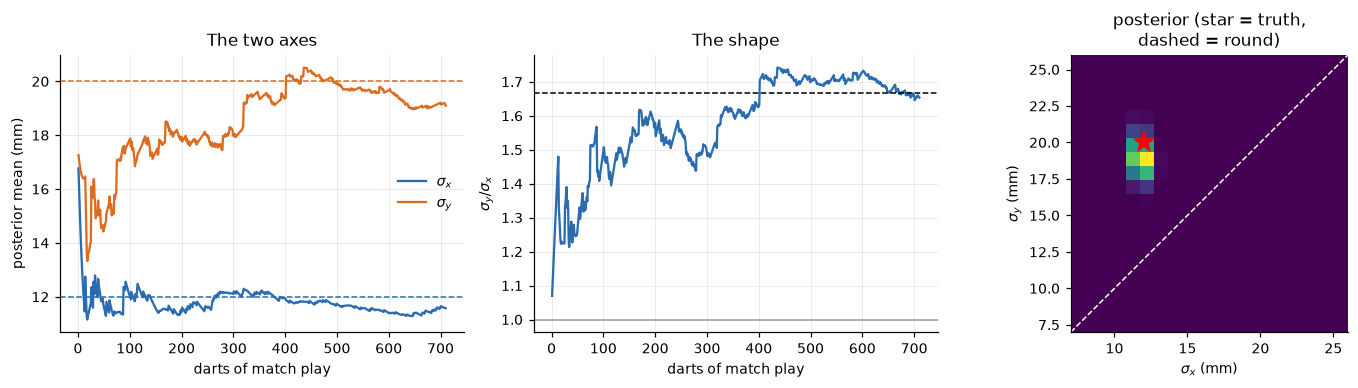

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
x = np.arange(1, len(hist) + 1)
axes[0].plot(x, hist.sigma_x, color='#2b6cb0', label=r'$\sigma_x$')
axes[0].plot(x, hist.sigma_y, color='#dd6b20', label=r'$\sigma_y$')
axes[0].axhline(12.0, color='#2b6cb0', ls='--', lw=1)
axes[0].axhline(20.0, color='#dd6b20', ls='--', lw=1)
axes[0].set_xlabel('darts of match play'); axes[0].set_ylabel('posterior mean (mm)')
axes[0].set_title('The two axes'); axes[0].legend()

axes[1].plot(x, hist.ratio, color='#2b6cb0')
axes[1].axhline(20.0 / 12.0, color='k', ls='--', lw=1)
axes[1].axhline(1.0, color='#999', lw=1)
axes[1].set_xlabel('darts of match play'); axes[1].set_ylabel(r'$\sigma_y / \sigma_x$')
axes[1].set_title('The shape')

w = post.marginal_sigma().reshape(len(FINE_SX), len(FINE_SY))
im = axes[2].imshow(w.T, origin='lower', cmap='viridis',
                    extent=[FINE_SX[0], FINE_SX[-1], FINE_SY[0], FINE_SY[-1]])
axes[2].plot(12.0, 20.0, 'r*', ms=14)
axes[2].plot([7, 26], [7, 26], color='w', ls='--', lw=1)
axes[2].set_xlabel(r'$\sigma_x$ (mm)'); axes[2].set_ylabel(r'$\sigma_y$ (mm)')
axes[2].set_title('posterior (star = truth,\ndashed = round)')
axes[2].grid(False)
fig.tight_layout()

In [10]:
# how quickly is the *shape* resolved, compared with the *size*?
marks = [100, 250, 500, len(hist)]
rows = []
for m in marks:
    if m > len(hist):
        continue
    rows.append({'darts': m,
                 'sigma_x': hist.sigma_x.iloc[m - 1],
                 'sigma_y': hist.sigma_y.iloc[m - 1],
                 'ratio': hist.ratio.iloc[m - 1]})
pd.DataFrame(rows).round(2)

,darts,sigma_x,sigma_y,ratio
0,100,12.03,17.84,1.50
1,250,11.59,18.00,1.56
2,500,11.73,19.91,1.70
3,710,11.58,19.10,1.65


The shape is learnable, and it does not take unreasonably long. From a prior that expects a
round throw (mean ratio 1.04) the posterior reaches a ratio of 1.50 after 100 darts, 1.56 by
250, 1.70 by 500, and settles near the true 1.67 with a standard deviation of 0.13.

But the *shape* resolves more slowly than the *size*, and the table shows exactly why. By 100
darts $\sigma_x$ has essentially arrived -- 12.03 against a truth of 12.0 -- while $\sigma_y$
is still 2.2 mm short, and it is the lagging axis that drags the ratio. The axes have to be
pinned down separately before their ratio means anything, and the ratio is a difference of two
noisy quantities. Roughly speaking, a couple of hundred darts gets you the overall spread, and it
takes something closer to a leg-heavy session -- several hundred -- before the shape is
worth acting on.

The posterior heat map makes the identifiability plain: the mass sits well off the diagonal,
which is the line of round throws. A few hundred darts of ordinary play are enough to rule
out "this player is round" quite firmly.

## Verdict

**Anisotropy passes on all three counts, and it is the expensive one.**

1. *Does the shape change the board?* Yes, and strongly. Holding the overall spread fixed,
   the chance of hitting a double varies by a factor of 1.37 across the board for a tall
   thrower, and the preferred doubles rotate 90 degrees between a tall player and a wide
   one. A round model cannot express any of this.
2. *Can the shape be learned?* Yes, from scores alone, though more slowly than the size: a
   couple of hundred darts for the axes, several hundred before the ratio is trustworthy.
3. *What does ignoring it cost?* About 0.11 visits per leg -- around a third of the cost of
   being wrong about the player's whole ability band.

There is also a result nobody was looking for: an anisotropic player is *better off* than a
round one with the same ellipse area, by 0.28 visits per leg. Error concentrated along one
axis can be pointed at the forgiving dimension of a bed; error spread evenly cannot.

The cost is computational. Every covariance needs its own MDP solve, so the grid is
two-dimensional -- 25 solves here, 150 seconds, against a single line of sigmas before.
That is affordable at this resolution and would not be at a much finer one.